**Agentic RAG implementation with Web based loader**

In [ ]:
!pip install langgraph
!pip install langchain-google-genai
!pip install langchain-community
!pip install langchain-chroma
!pip install langchain-huggingface
!pip install beautifulsoup4

  Using cached langchain_chroma-1.1.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached chromadb-1.5.9-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.0 kB)
  Using cached build-1.6.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached pybase64-1.5.0-cp313-cp313-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (11 kB)
  Using cached onnxruntime-1.29.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (5.6 kB)
  Using cached opentelemetry_exporter_otlp_proto_grpc-1.44.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached pypika-0.51.1-py2.py3-none-any.whl.metadata (51 kB)
  Using cached overrides-7.7.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 76.8 

^C


In [2]:
import warnings
warnings.filterwarnings('ignore')

# Re-install langchain-huggingface as its previous installation was interrupted
!pip install langchain-huggingface

  Using cached langchain_huggingface-1.2.2-py3-none-any.whl.metadata (4.0 kB)
Using cached langchain_huggingface-1.2.2-py3-none-any.whl (31 kB)


In [3]:
#import libaries
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

In [6]:
#import models and store embeddings into chroma db
from google.colab import userdata
llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash",temperature=0,api_key=userdata.get("GEMINI"))

urls = [
    "https://en.wikipedia.org/wiki/Artificial_intelligence",
    "https://en.wikipedia.org/wiki/Machine_learning"]

#Web RAG

docs = WebBaseLoader(web_paths=urls).load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectorstore = Chroma.from_documents(documents=text_splitter, embedding=embeddings)

retriever = vectorstore.as_retriever(search_kwargs={"k":4})

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [12]:
#Agentic RAG
class State(TypedDict):
  question:str
  context:str
  answer:str

def agent(state):
  r = llm.invoke(
      f"""Does this requires answer from the web?
      Question:{state['question']}
      Answer only YES or NO."""
  )
  llm_response_content = r.content

  # Ensure llm_response_content is a string. If it's a list, convert to string.
  if isinstance(llm_response_content, list):
    llm_response_str = " ".join(map(str, llm_response_content))
  else:
    llm_response_str = str(llm_response_content) # Ensure it's a string

  # Normalize the response to extract 'YES' or 'NO'
  if 'YES' in llm_response_str.upper():
    extracted_answer = "YES"
  elif 'NO' in llm_response_str.upper():
    extracted_answer = "NO"
  else:
    # Default to 'NO' if the response is ambiguous or unexpected
    extracted_answer = "NO"

  return {**state, "context": extracted_answer}

def retrieve(state):
  docs = retriever.invoke(state["question"])
  context = "\n\n".join(doc.page_content for doc in docs)
  return {**state, "context":context}

def generate(state):
  r = llm.invoke(
        f"""Answer using the context.

Question: {state['question']}

Context:
{state['context']}

If the context is insufficient, say you don\'t have enough information."""
    )
  return {**state, "answer": r.content}

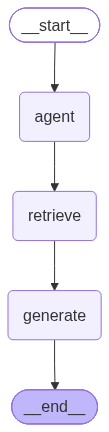

In [14]:
#Build Graph
graph = StateGraph(State)

graph.add_node("agent",agent)
graph.add_node("retrieve",retrieve)
graph.add_node("generate",generate)

graph.add_edge(START,"agent")
graph.add_edge("agent","retrieve")
graph.add_edge("retrieve","generate")

graph.set_entry_point("agent")

graph.add_conditional_edges(
    "agent",
    lambda s: "retrieve" if s["context"].upper() =="YES" else "generate"
)
graph.add_edge("retrieve","generate")
graph.add_edge("generate",END)

app = graph.compile()
app

In [ ]:
#invoke
result = app.invoke({
    "question": "What is artificial intelligence?",
    "context": "",
    "answer": ""
})

print(result["answer"])